In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
import pandas as pd
import numpy as np
%config InlineBackend.figure_formats = ['svg']

In [2]:
def parse_tango_changes(file_name: str) -> [float]:
    result = []
    significant = []
    with open(file_name) as f:
        for line in f:
            #print(line)
            
            matches = re.findall(r"([-+][0-9]+.[0-9]+)%(\*?)$", line)[0]
            #print(matches[1] == "*")
            result.append(float(matches[0]))
            significant.append(matches[1] == "*")
    return result, significant

In [3]:
!tar xvf a5adc133-fe36-48b4-9085-bf7a651f4b7c.tar.gz

result/
result/hostname
result/aws_instance_type
result/cpuinfo
result/commpage.txt
result/free
result/main.txt


In [4]:
experiment_path = "result"

main, main_significant = parse_tango_changes(f"{experiment_path}/main.txt")
commpage, commpage_significant = parse_tango_changes(f"{experiment_path}/commpage.txt")

N = min(len(main), len(commpage))

data = pd.DataFrame({
    'main': main[:N],
    'commpage': commpage[:N],
})

significant = pd.DataFrame({
    'main': main_significant[:N],
    'commpage': commpage_significant[:N],
})

display(data.describe())

,main,commpage
count,1000.000000,1000.000000
mean,-0.140850,-0.001770
std,2.470347,1.693929
min,-41.030000,-10.850000
25%,-0.180000,-0.100000
50%,0.020000,-0.050000
75%,0.200000,0.012500
max,13.040000,52.110000


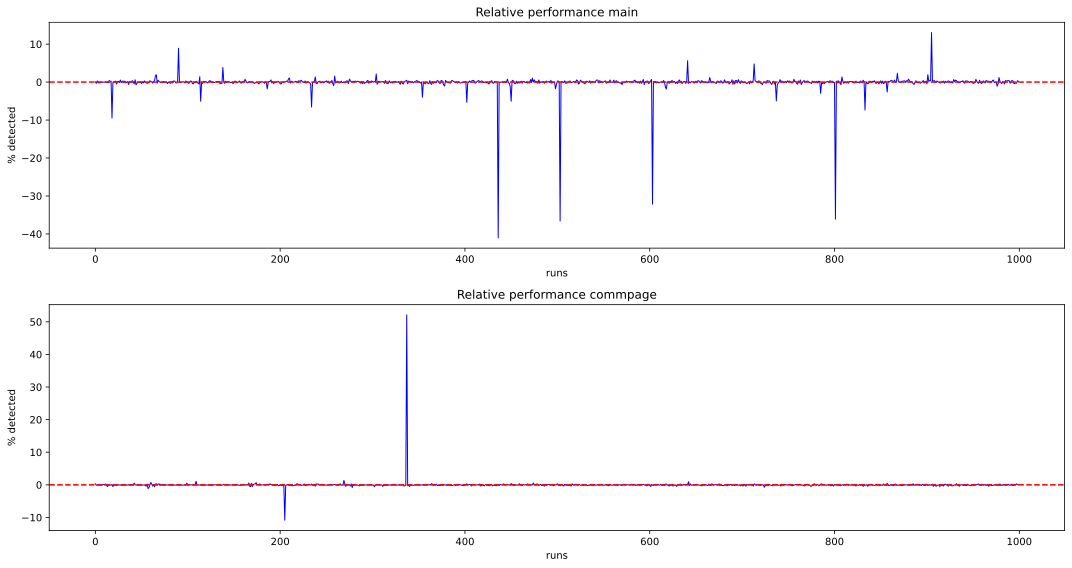

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

for ax, col in zip(axes, data.columns):
    ax.plot(data.index, data[col], color='blue', label="Tango", linewidth=1)
    ax.set_title(f'Relative performance {col}')
    ax.set_xlabel('runs')
    ax.set_ylabel('% detected')
    #ax.set_yscale('symlog')

    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

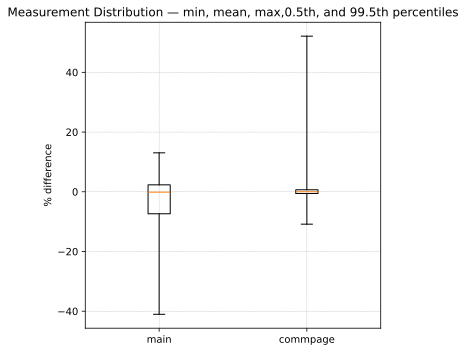

In [11]:
LOW = 0.5
HIGH = 99.5

def make_boxplot_stats(input):
    q1, q3 = np.percentile(input, [LOW, HIGH])
    return {
        'med':    np.mean(input),
        'q1':     q1,
        'q3':     q3,
        'whislo': np.min(input),
        'whishi': np.max(input),
        'fliers': []
    }

fig, ax = plt.subplots(figsize=(5, 5))

ax.bxp([make_boxplot_stats(data[col]) for col in data.columns], positions=range(1, len(data.columns) + 1), showfliers=False)

#ax.set_yscale('symlog')
#ax.set_yticks([-100, -20, -10, -1, 0, 1, 10, 20, 100])

ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_title('')
ax.set_title(f'Measurement Distribution — min, mean, max,{LOW}th, and {HIGH}th percentiles')
ax.set_ylabel('% difference')
ax.set_xticklabels(data.columns)
ax.grid(linestyle='--', linewidth=0.4)

plt.tight_layout()
plt.show()

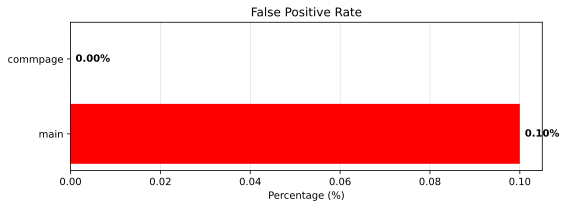

In [7]:
fig, ax = plt.subplots(figsize=(8, 3))

bars = ax.barh(significant.columns, significant.mean() * 100, color='red')

ax.bar_label(bars, fmt='%.2f%%', padding=5, fontweight="bold")

ax.set_xlabel('Percentage (%)')
ax.set_title('False Positive Rate')

ax.grid(linestyle='--', linewidth=0.4, axis='x')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()